In [7]:
import re
import os
from itertools import combinations
from ast import literal_eval
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

In [8]:
z = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/z_score.csv', index_col=0)
pvals_adj = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/pval_adj.csv', index_col=0)
significant = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/significant.csv', index_col=0)

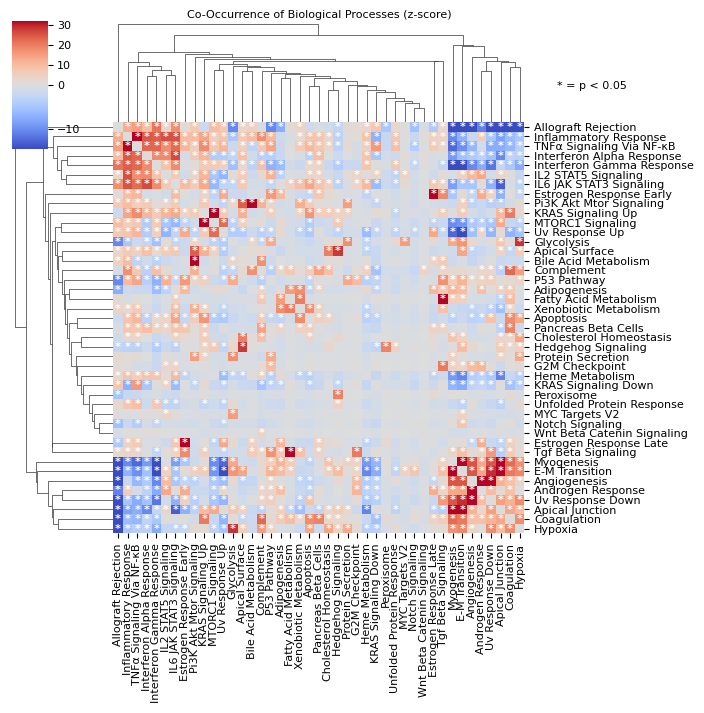

In [14]:

# =========================================================
# GLOBAL FONT SIZE
# =========================================================
fs = 8
plt.rcParams.update({'font.size': fs})

# =========================================================
# NORMALIZATION
# =========================================================
vmin = np.percentile(z, 1)
vmax = np.percentile(z, 99)

norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# =========================================================
# CLUSTERMAP
# =========================================================
g = sns.clustermap(
    z,
    cmap='coolwarm',
    norm=norm,
    figsize=(7.08, 7.08),
    xticklabels=True,
    yticklabels=True
)

# force tick label sizes
g.ax_heatmap.tick_params(labelsize=fs)
g.ax_row_dendrogram.tick_params(labelsize=fs)
g.ax_col_dendrogram.tick_params(labelsize=fs)

# =========================================================
# REORDER SIGNIFICANCE
# =========================================================
sig_reordered = significant.iloc[
    g.dendrogram_row.reordered_ind,
    g.dendrogram_col.reordered_ind
]

ax = g.ax_heatmap

# =========================================================
# STARS
# =========================================================
for i in range(sig_reordered.shape[0]):
    for j in range(sig_reordered.shape[1]):
        if sig_reordered.iat[i, j]:
            ax.text(
                j + 0.5,
                i + 0.5,
                "*",
                ha='center',
                va='center',
                color='white',
                fontsize=fs,
                fontweight='bold'
            )

# =========================================================
# TITLE + ANNOTATION
# =========================================================
ax.set_title(
    "Co-Occurrence of Biological Processes (z-score)",
    fontsize=fs,
    pad=75
)

ax.text(
    1.25, 1.1,
    '* = p < 0.05',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=fs
)

# Save
name = 'S4'
figures_dir = '/home/lnemati/pathway_crosstalk/results/figures/new_figures'
os.makedirs(os.path.join(figures_dir, name), exist_ok=True)

plt.savefig(os.path.join(figures_dir, name, name) + '.pdf', bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(figures_dir, name, name) + '.png', bbox_inches='tight', dpi=300)

plt.show()


In [24]:
import re
import os
from itertools import combinations
from ast import literal_eval
from tqdm import tqdm
import pandas as pd
import numpy as np
from scipy.stats import false_discovery_control
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import os
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm


In [25]:

# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'


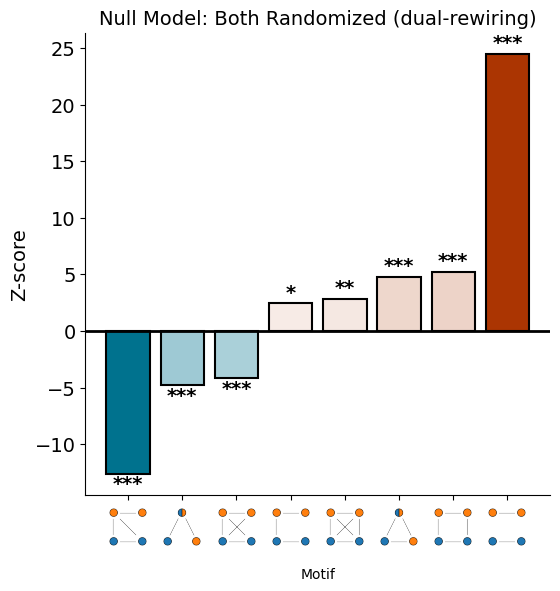

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'
fs = 14

df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/both_shuffle/motifs_permutations.csv')
counts = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/counts_real.csv')

# -------------------------
# Real motif counts
# -------------------------
motifs = counts.set_index('motif')['number']

# -------------------------
# Split motif classes
# -------------------------
df3 = df[[c for c in df.columns if c.startswith('3')]]
df4 = df[[c for c in df.columns if c.startswith('4')]]

motifs3 = motifs.loc[[i for i in motifs.index if i.startswith('3')]]
motifs4 = motifs.loc[[i for i in motifs.index if i.startswith('4')]]

# normalize real counts
motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()

# normalize null distributions
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df_model = df3.join(df4)
motifs_model = pd.concat([motifs3, motifs4])

# -------------------------
# Z-score computation
# -------------------------
means = df_model.mean()
stds = df_model.std().replace(0, np.nan)

motifs_z = ((motifs_model - means) / stds).dropna().sort_values()
motifs_z.name = 'z'

motifs_names = motifs_z.index
z_scores = motifs_z.values

# -------------------------
# Color mapping
# -------------------------
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_gradient', [ncolor, 'white', tcolor]
)
norm = mcolors.TwoSlopeNorm(
    vmin=np.nanmin(z_scores),
    vcenter=0,
    vmax=np.nanmax(z_scores)
)
colors = cmap(norm(z_scores))

# -------------------------
# Plot bars
# -------------------------
bars = ax.bar(
    motifs_names,
    z_scores,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

ax.axhline(0, color='black', linewidth=2)
ax.set_ylabel("Z-score", fontsize=fs)

# -------------------------
# Significance (FDR)
# -------------------------
null_center = np.mean(df_model, axis=0)

p_values = (
    (np.abs(motifs_model - null_center) <= np.abs(df_model - null_center)).sum(axis=0)
    / df_model.shape[0]
)

p_values = pd.Series(false_discovery_control(p_values), index=p_values.index)
p_values = p_values.reindex(motifs_names)

sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

for bar, z, p in zip(bars, z_scores, p_values):
    if pd.isna(p):
        continue

    sig_symbol = next((s for thr, s in sig_levels.items() if p <= thr), None)

    if sig_symbol:
        y = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            y + (0.1 if y > 0 else -0.1),
            sig_symbol,
            ha='center',
            va='bottom' if y > 0 else 'top',
            fontsize=fs,
            fontweight='bold'
        )

# -------------------------
# Titles / styling
# -------------------------
ax.set_title('Null Model: Both Randomized (dual-rewiring)', fontsize=14)

ax.set_xticklabels([])
ax.set_xlabel("Motif", labelpad=45)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', labelsize=fs)

# -------------------------
# Add motif icons 
# -------------------------
img_width = 0.7
img_height = img_width
y_icons_offset = 0.42

for tick_x, label in zip(ax.get_xticks(), motifs_names):
    img_path = os.path.join(img_dir, f"{label}.png")

    if os.path.exists(img_path):
        img = mpimg.imread(img_path)

        inset_ax = ax.inset_axes(
            [tick_x - img_width/2, -y_icons_offset, img_width, img_height],
            transform=ax.get_xaxis_transform(),
            zorder=10
        )

        inset_ax.imshow(img)
        inset_ax.axis('off')

plt.show()

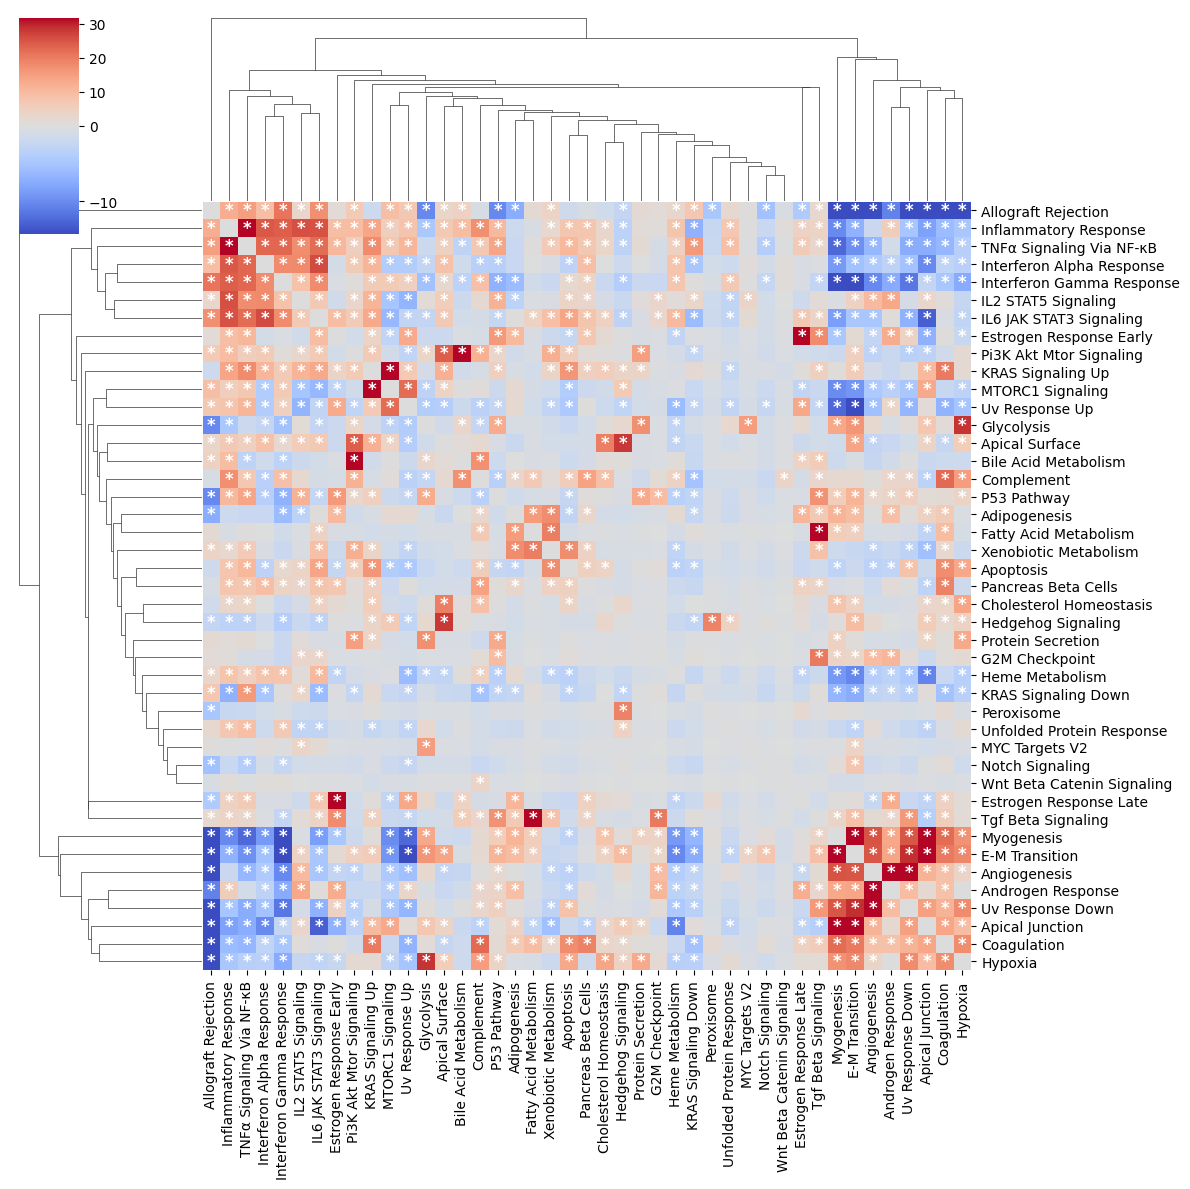

In [23]:
z = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/z_score.csv', index_col=0)
pvals_adj = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/pval_adj.csv', index_col=0)
significant = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/significant.csv', index_col=0)

# Compute percentiles
vmin = np.percentile(z, 1)
vmax = np.percentile(z, 99)

#vmin = np.min(log_ratio)
#vmax = np.max(log_ratio)

# Create normalization centered at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

g = sns.clustermap(
    z,
    cmap='coolwarm',
    #center=0,
    norm=norm,
    figsize=(12, 12)
)

# --- Reorder significance matrix to match clustering ---
# (this is the key step!)
sig_reordered = significant.iloc[
    g.dendrogram_row.reordered_ind,
    g.dendrogram_col.reordered_ind
]

# --- Add stars ---
ax = g.ax_heatmap

for i in range(sig_reordered.shape[0]):
    for j in range(sig_reordered.shape[1]):
        if sig_reordered.iat[i, j]:
            ax.text(
                j + 0.5, i + 0.5,
                "*",
                ha='center', va='center',
                color='white', fontsize=12, fontweight='bold'
            )
    
plt.show()

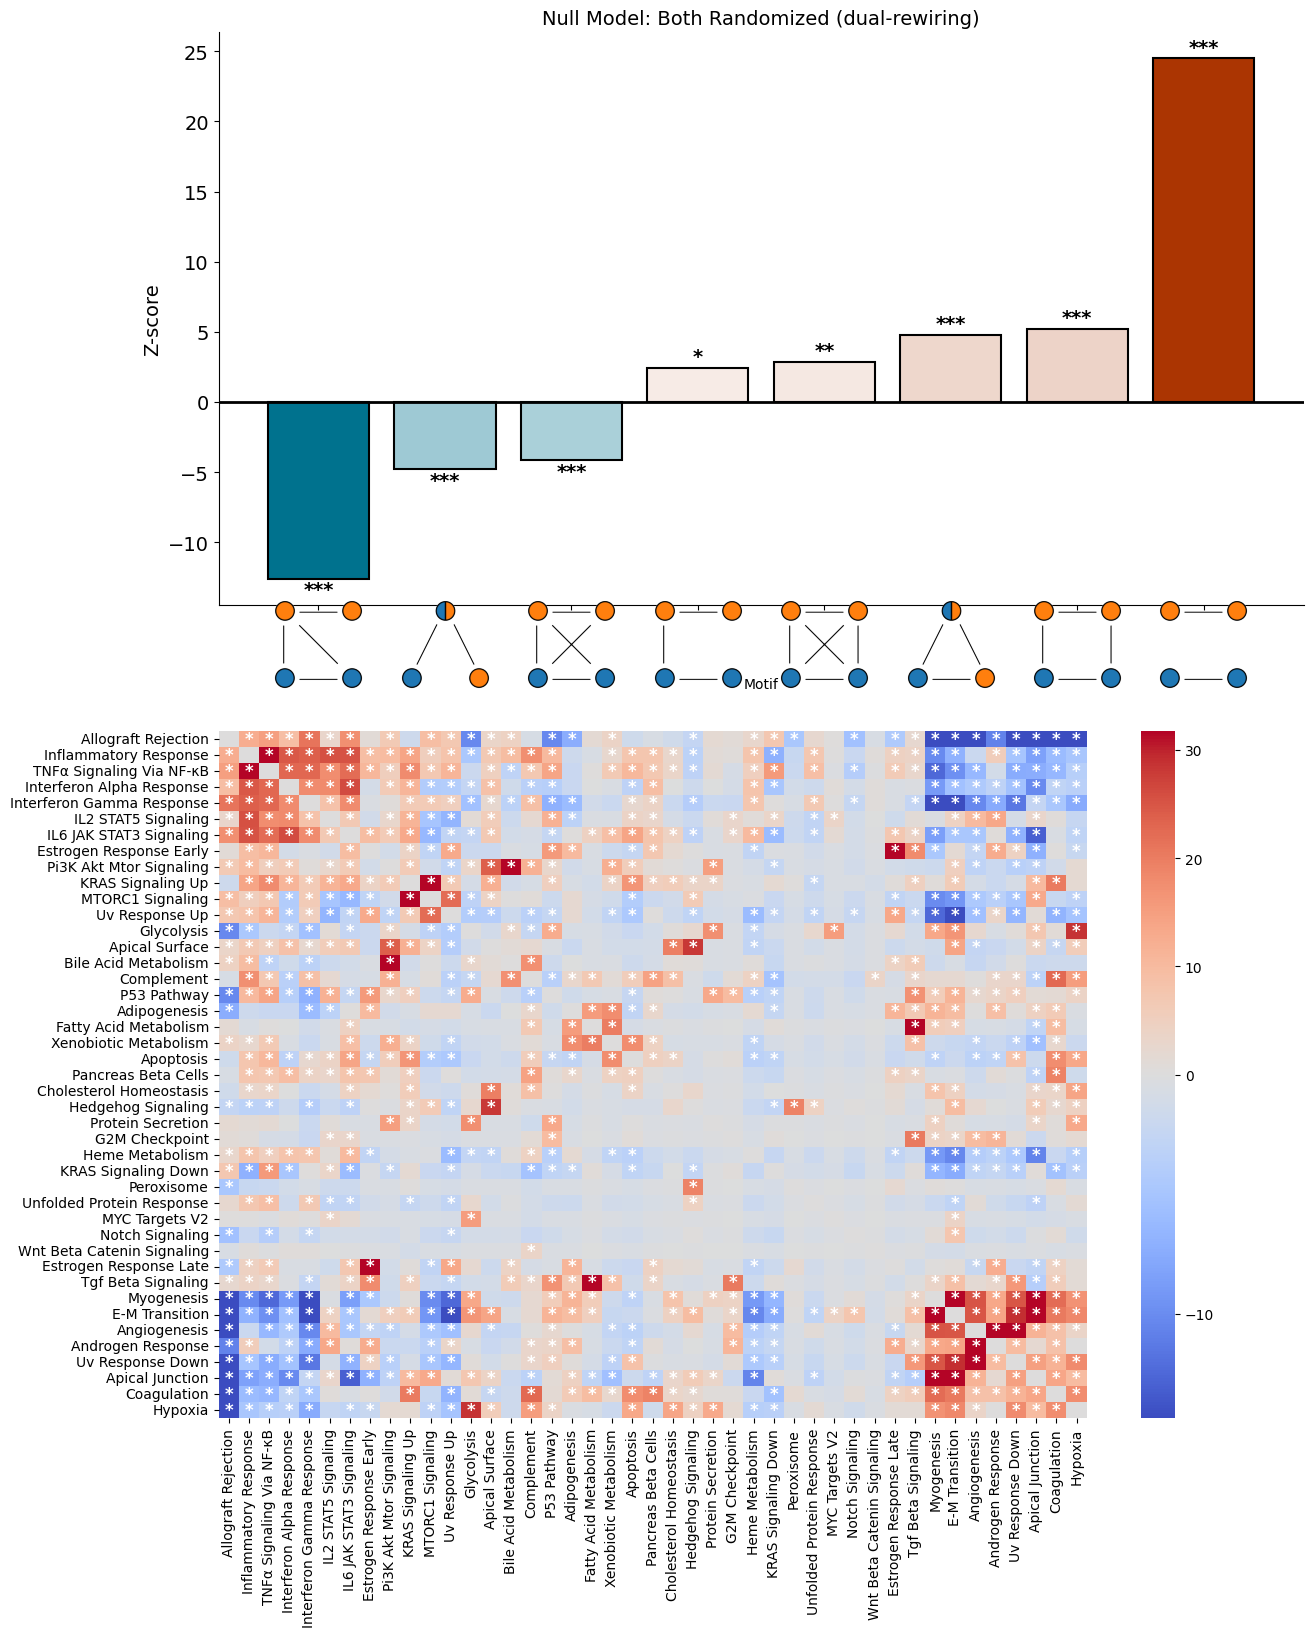

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
from matplotlib.colors import TwoSlopeNorm

# =========================================================
# LOAD DATA (PLOT 1)
# =========================================================
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'

df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/both_shuffle/motifs_permutations.csv')
counts = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/counts_real.csv')

motifs = counts.set_index('motif')['number']

df3 = df[[c for c in df.columns if c.startswith('3')]]
df4 = df[[c for c in df.columns if c.startswith('4')]]

motifs3 = motifs.loc[[i for i in motifs.index if i.startswith('3')]]
motifs4 = motifs.loc[[i for i in motifs.index if i.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()

df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df_model = df3.join(df4)
motifs_model = pd.concat([motifs3, motifs4])

means = df_model.mean()
stds = df_model.std().replace(0, np.nan)

motifs_z = ((motifs_model - means) / stds).dropna().sort_values()
motifs_z.name = 'z'

motifs_names = motifs_z.index
z_scores = motifs_z.values

cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_gradient', [ncolor, 'white', tcolor]
)

norm_bar = mcolors.TwoSlopeNorm(
    vmin=np.nanmin(z_scores),
    vcenter=0,
    vmax=np.nanmax(z_scores)
)
colors = cmap(norm_bar(z_scores))

null_center = np.mean(df_model, axis=0)

p_values = (
    (np.abs(motifs_model - null_center) <= np.abs(df_model - null_center)).sum(axis=0)
    / df_model.shape[0]
)

p_values = pd.Series(false_discovery_control(p_values), index=p_values.index)
p_values = p_values.reindex(motifs_names)

sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

# =========================================================
# LOAD DATA (PLOT 2)
# =========================================================
z = pd.read_csv(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/z_score.csv',
    index_col=0
)

significant = pd.read_csv(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/processes_z/significant.csv',
    index_col=0
)

# clustering order
g = sns.clustermap(
    z,
    cmap='coolwarm',
    norm=TwoSlopeNorm(
        vmin=np.percentile(z, 1),
        vcenter=0,
        vmax=np.percentile(z, 99)
    ),
    figsize=(6, 6)
)

row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind
plt.close(g.fig)

z_ord = z.iloc[row_order, col_order]
sig_ord = significant.iloc[row_order, col_order]

# =========================================================
# FIGURE LAYOUT (MOSAIC)
# =========================================================
mosaic = """
AAA
BBB
"""

fig, axd = plt.subplot_mosaic(
    mosaic,
    figsize=(14, 18),
    gridspec_kw={"height_ratios": [1, 1.2]}
)

ax1 = axd["A"]
ax2 = axd["B"]

# =========================================================
# PLOT 1 — BAR PLOT
# =========================================================
bars = ax1.bar(
    motifs_names,
    z_scores,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

ax1.axhline(0, color='black', linewidth=2)
ax1.set_ylabel("Z-score", fontsize=14)
ax1.set_title('Null Model: Both Randomized (dual-rewiring)', fontsize=14)

ax1.set_xticklabels([])
ax1.set_xlabel("Motif", labelpad=45)

ax1.spines[['right', 'top']].set_visible(False)
ax1.tick_params(axis='both', labelsize=14)

# significance
for bar, p in zip(bars, p_values):
    if pd.isna(p):
        continue
    sig_symbol = next((s for thr, s in sig_levels.items() if p <= thr), None)
    if sig_symbol:
        y = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            y + (0.1 if y > 0 else -0.1),
            sig_symbol,
            ha='center',
            va='bottom' if y > 0 else 'top',
            fontsize=14,
            fontweight='bold'
        )

# motif icons
img_width = 0.7
y_icons_offset = 0.42

for tick_x, label in zip(ax1.get_xticks(), motifs_names):
    img_path = os.path.join(img_dir, f"{label}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        inset_ax = ax1.inset_axes(
            [tick_x - img_width/2, -y_icons_offset, img_width, img_width],
            transform=ax1.get_xaxis_transform()
        )
        inset_ax.imshow(img)
        inset_ax.axis('off')

# =========================================================
# PLOT 2 — HEATMAP
# =========================================================
norm_heat = TwoSlopeNorm(
    vmin=np.percentile(z_ord.values, 1),
    vcenter=0,
    vmax=np.percentile(z_ord.values, 99)
)

sns.heatmap(
    z_ord,
    cmap='coolwarm',
    norm=norm_heat,
    ax=ax2,
    cbar=True
)

# significance stars
for i in range(sig_ord.shape[0]):
    for j in range(sig_ord.shape[1]):
        if sig_ord.iat[i, j]:
            ax2.text(
                j + 0.5,
                i + 0.5,
                "*",
                ha='center',
                va='center',
                color='white',
                fontsize=12,
                fontweight='bold'
            )

ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.show()